# 06 — Model Evaluation & Comparison

Summarize the recorded training metrics and validate that all four serialized production model artifacts can be loaded.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import json
import pandas as pd
import joblib

metrics=json.loads((ROOT/'reports/training_metrics.json').read_text(encoding='utf-8'))
comparison=pd.read_csv(ROOT/'reports/model_comparison.csv')
display(comparison)
print('Training report version:',metrics.get('version'))
print('Dataset rows:',metrics.get('dataset'))

,module,mae,rmse,r2,accuracy,f1,roc_auc,f1_macro
0,loan_amount,30814.579464,47756.225410,0.948532,NaN,NaN,NaN,NaN
1,loan_approval,NaN,NaN,NaN,0.773333,0.318296,0.742628,NaN
2,credit_score,15.007433,19.145375,0.862029,NaN,NaN,NaN,NaN
3,credit_risk,NaN,NaN,NaN,0.817917,NaN,NaN,0.577951


Training report version: 2.0.0
Dataset rows: {'loan_rows': 12000, 'risk_rows': 12000}


In [3]:
artifact_sizes=[]
for name in ['loan_amount.joblib','loan_approval.joblib','credit_score.joblib','credit_risk.joblib']:
    path=ROOT/'models'/name
    artifact_sizes.append({'model':name,'exists':path.exists(),'size_mb':round(path.stat().st_size/1024**2,2) if path.exists() else None})
    if path.exists():
        obj=joblib.load(path)
        print(name,'loaded as',type(obj).__name__)
display(pd.DataFrame(artifact_sizes))

c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead 

loan_amount.joblib loaded as Pipeline


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingRegressor from version 1.8.0 when using versi

loan_approval.joblib loaded as Pipeline
credit_score.joblib loaded as Pipeline
credit_risk.joblib loaded as dict


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,model,exists,size_mb
0,loan_amount.joblib,True,24.34
1,loan_approval.joblib,True,53.33
2,credit_score.joblib,True,0.33
3,credit_risk.joblib,True,67.18


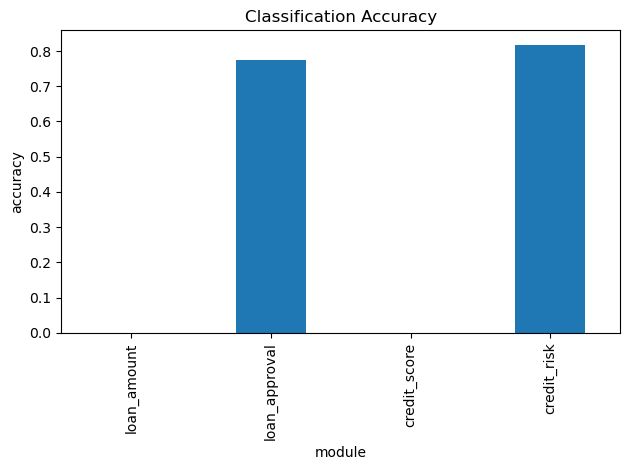

In [4]:
import matplotlib.pyplot as plt

# Plot only metrics that are present in the recorded comparison report.
metric='accuracy'
if metric in comparison.columns:
    comparison.plot(x='module',y=metric,kind='bar',legend=False,title='Classification Accuracy')
    plt.ylabel(metric); plt.tight_layout(); plt.show()

## Reproducibility
The authoritative retraining entry point is `python -m src.train` (or `python scripts/retrain.py`). These notebooks are intended for inspection, evaluation, and presentation; they do not silently replace production artifacts.